# 🚗 Car Price Prediction using Machine Learning

**OASIS Infobyte Data Science Internship — Task 3**

**Objective:**  
Build a machine learning model to predict car prices based on various features of the car.

**Dataset:** Car Price Dataset

**Algorithm:** Random Forest Regressor

**Data Processing:** Data Preprocessing & Categorical Feature Encoding

**Model Evaluation:** Actual vs Predicted Car Prices

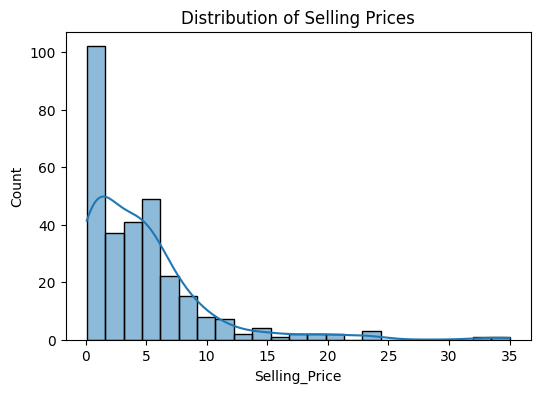

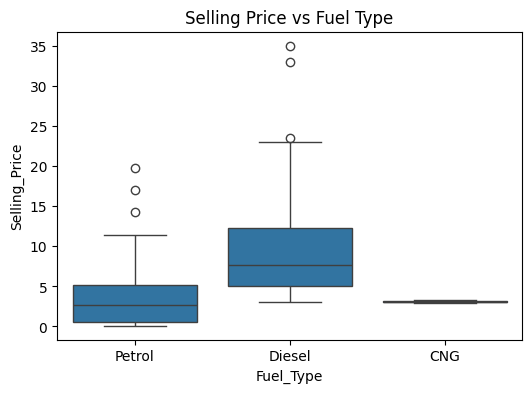

=== Linear Regression Performance ===
MAE     : 1.47
RMSE    : 2.52
R² Score: 0.7527

=== Random Forest Regressor Performance ===
MAE     : 1.47
RMSE    : 3.51
R² Score: 0.5221



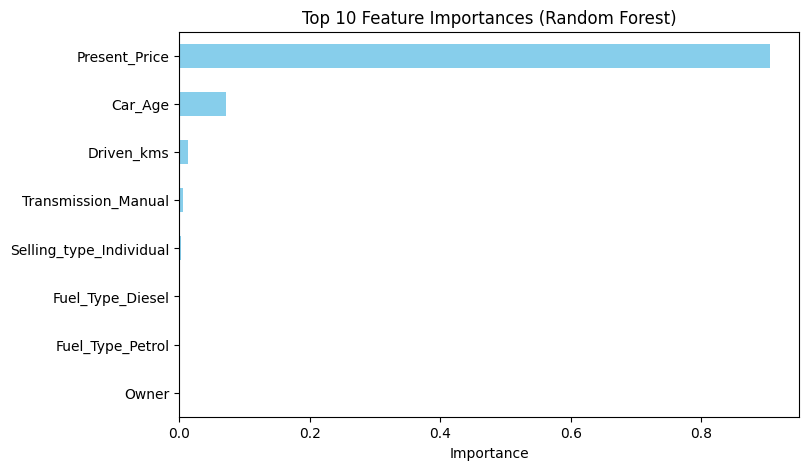

In [ ]:
import zipfile, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Extract and Load Dataset
zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]
if zip_files:
    with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
        zip_ref.extractall('.')

csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
df = pd.read_csv(csv_files[0])

# Clean column headers
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)

# 2. Feature Engineering
if 'Year' in df.columns:
    df['Car_Age'] = 2026 - df['Year']

if 'Car_Name' in df.columns:
    df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split()[0])

# 3. Exploratory Data Analysis (EDA) Visualizations
plt.figure(figsize=(6, 4))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Selling Prices')
plt.show()

if 'Fuel_Type' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
    plt.title('Selling Price vs Fuel Type')
    plt.show()

# 4. Prepare X and y (Convert ALL string columns to numbers)
# Columns to exclude from features
cols_to_drop = [c for c in ['Selling_Price', 'Car_Name', 'Brand', 'Year'] if c in df.columns]

X_raw = df.drop(columns=cols_to_drop)
y = df['Selling_Price']

# Convert ALL categorical text columns into one-hot numeric columns
X = pd.get_dummies(X_raw, drop_first=True)

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train 2 Regression Models
lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)

# 7. Evaluate Models (MAE, RMSE, R2 Score)
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} Performance ===")
    print(f"MAE     : {mae:.2f}")
    print(f"RMSE    : {rmse:.2f}")
    print(f"R² Score: {r2:.4f}\n")

print_metrics(y_test, pred_lr, "Linear Regression")
print_metrics(y_test, pred_rf, "Random Forest Regressor")

# 8. Feature Importance Plot
plt.figure(figsize=(8, 5))
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()